<a href="https://colab.research.google.com/github/Chameleon-company/MOP-Code/blob/Renewable_energy_opportunity/Playground/Sriraam/MOP_Model_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MOP — Melbourne Solar Rooftop Opportunity Mapping
## Modelling & Visualisation Notebook — Version 2

**Pipeline:**
1. Load cleaned outputs from `MOP_Cleaning_V2.ipynb`
2. Spatial join: solar polygons → building footprints
3. Building-level aggregation with composite opportunity score
4. Land-use breakdown of solar potential
5. Statistical charts (4-panel dashboard)
6. Interactive Folium map with popups
7. Top-20 priority buildings table

---

##  Setup & Imports

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install geopandas mapclassify folium -q

In [4]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import folium
from folium.plugins import MarkerCluster
import warnings
warnings.filterwarnings('ignore')

BASE_PATH   = '/content/drive/MyDrive/Colab Notebooks/MOP/'
OUT_SOLAR   = BASE_PATH + 'solar_clean.gpkg'
OUT_FP      = BASE_PATH + 'footprints_clean.gpkg'

RATING_SCORE = {
    'Excellent': 1.00,
    'Good':      0.75,
    'Moderate':  0.50,
    'Poor':      0.25,
    'Very Poor': 0.10
}

RATING_COLOR = {
    'Excellent': '#1B5E38',
    'Good':      '#5B9BD5',
    'Moderate':  '#F0A500',
    'Poor':      '#E05C5C',
    'Very Poor': '#AAAAAA'
}

STATUS_COLOR = {
    'COMPLETED':          '#5B9BD5',
    'UNDER CONSTRUCTION': '#1B5E38',
    'APPROVED':           '#F0A500',
    'APPLIED':            '#AAAAAA'
}

print('Libraries loaded.')

Libraries loaded.


---
##  Load Cleaned Datasets

In [5]:
solar      = gpd.read_file(OUT_SOLAR)
footprints = gpd.read_file(OUT_FP)

print(f'Solar  : {len(solar):,} rows | CRS: {solar.crs}')
print(f'Footp. : {len(footprints):,} rows | CRS: {footprints.crs}')

# Confirm CRS match
assert solar.crs == footprints.crs, 'CRS mismatch — re-run Cleaning notebook!'
print('CRS match ✓')

Solar  : 99,766 rows | CRS: EPSG:28355
Footp. : 1,274 rows | CRS: EPSG:28355
CRS match ✓


---
##  Spatial Join — Solar Polygons → Building Footprints

**V2 improvement:** We use `how='left'` on solar (keeping all solar polygons) then
filter to those that matched a footprint.  This allows us to also report the total
unmatched solar opportunity across the broader city (outside tracked developments).

In [6]:
print('Running spatial join…')

# Only join against actionable footprints to keep the main analysis clean
fp_actionable = footprints[footprints['is_actionable']].copy()

joined = gpd.sjoin(
    solar,
    fp_actionable[['dev_key', 'status', 'address',
                   'bldhgt_ahd', 'building_height_m', 'num_floors',
                   'land_use_1', 'shape_type', 'priority_target', 'geometry']],
    how='inner',
    predicate='intersects'
)

print(f'Matched solar rooftop polygons : {len(joined):,}')
print(f'Unique buildings matched       : {joined["dev_key"].nunique():,}')
print(f'Columns: {list(joined.columns)}')

Running spatial join…
Matched solar rooftop polygons : 8,113
Unique buildings matched       : 334
Columns: ['Shape_Leng', 'Shape_Area', 'RATING', 'is_outlier_large', 'usable_area_m2', 'rating_score', 'est_kwh_year', 'est_co2_offset_kg_year', 'geometry', 'index_right', 'dev_key', 'status', 'address', 'bldhgt_ahd', 'building_height_m', 'num_floors', 'land_use_1', 'shape_type', 'priority_target']


---
##  Building-Level Aggregation

**V2 additions:**
- `excellent_good_pct` — share of rooftop in Excellent/Good categories
- `composite_score` — weighted combination of energy potential + rating quality
- `est_mwh_year` — energy in MWh (more readable)
- `est_co2_offset_t_year` — CO₂ offset in tonnes
- `num_homes_equivalent` — approx. homes that could be powered (Melbourne avg: ~5,000 kWh/yr)

In [7]:
def dominant(series):
    """Return the most common value in a series."""
    return series.value_counts().index[0]

building_summary = (
    joined.groupby(
        ['dev_key', 'address', 'status', 'building_height_m',
         'num_floors', 'land_use_1', 'shape_type', 'priority_target']
    )
    .agg(
        total_rooftop_area_m2  = ('Shape_Area',      'sum'),
        usable_area_m2         = ('usable_area_m2',   'sum'),
        avg_rating_score       = ('rating_score',     'mean'),
        dominant_rating        = ('RATING',           dominant),
        est_kwh_year           = ('est_kwh_year',     'sum'),
        est_co2_offset_kg_year = ('est_co2_offset_kg_year', 'sum'),
        rooftop_count          = ('RATING',           'count'),
        excellent_count        = ('RATING', lambda x: (x.isin(['Excellent'])).sum()),
        good_count             = ('RATING', lambda x: (x.isin(['Good'])).sum()),
    )
    .reset_index()
)

# Derived columns
building_summary['est_mwh_year']            = (building_summary['est_kwh_year'] / 1000).round(2)
building_summary['est_co2_offset_t_year']   = (building_summary['est_co2_offset_kg_year'] / 1000).round(2)
building_summary['num_homes_equivalent']    = (building_summary['est_kwh_year'] / 5000).round(1)
building_summary['excellent_good_pct']      = (
    (building_summary['excellent_count'] + building_summary['good_count'])
    / building_summary['rooftop_count'] * 100
).round(1)

# Composite score: 70 % energy potential (normalised) + 30 % quality
max_mwh = building_summary['est_mwh_year'].max()
building_summary['composite_score'] = (
    0.70 * (building_summary['est_mwh_year'] / max_mwh) +
    0.30 * building_summary['avg_rating_score']
).round(4)

# Rank by composite score
building_summary = building_summary.sort_values('composite_score', ascending=False).reset_index(drop=True)
building_summary['rank'] = building_summary.index + 1

print(f'Total buildings analysed    : {len(building_summary):,}')
print(f'Under Construction (priority): {building_summary["priority_target"].sum():,}')
print()
print('=== KEY FINDINGS ===')
print(f'Total matched rooftop polygons  : {len(joined):,}')
print(f'Total usable rooftop area       : {building_summary["usable_area_m2"].sum():,.0f} m²')
print(f'Total est. energy generation    : {building_summary["est_mwh_year"].sum():,.0f} MWh/year')
print(f'Total est. CO₂ offset           : {building_summary["est_co2_offset_t_year"].sum():,.0f} tonnes/year')
print(f'Homes equivalent (5,000 kWh/yr) : {building_summary["num_homes_equivalent"].sum():,.0f} homes')
print(f'Avg generation per building     : {building_summary["est_mwh_year"].mean():,.1f} MWh/year')

Total buildings analysed    : 569
Under Construction (priority): 108

=== KEY FINDINGS ===
Total matched rooftop polygons  : 8,113
Total usable rooftop area       : 913,050 m²
Total est. energy generation    : 151,345 MWh/year
Total est. CO₂ offset           : 124,103 tonnes/year
Homes equivalent (5,000 kWh/yr) : 30,269 homes
Avg generation per building     : 266.0 MWh/year


In [8]:
print('--- Top 15 Buildings by Composite Score ---')
building_summary[
    ['rank', 'address', 'status', 'dominant_rating',
     'usable_area_m2', 'est_mwh_year', 'est_co2_offset_t_year',
     'num_homes_equivalent', 'composite_score']
].head(15).to_string(index=False)

--- Top 15 Buildings by Composite Score ---


' rank                                                    address             status dominant_rating  usable_area_m2  est_mwh_year  est_co2_offset_t_year  num_homes_equivalent  composite_score\n    1                    130-188 Todd Road, Port Melbourne, 3207 UNDER CONSTRUCTION            Poor         26832.0       4686.46                3842.90                 937.3           0.7620\n    2               512-544 Spencer Street, West Melbourne, 3003          COMPLETED            Good          7335.0       1549.31                1270.44                 309.9           0.4356\n    3                    2-50 Elizabeth Street, Kensington, 3031          COMPLETED            Good          4917.0       1292.19                1059.59                 258.4           0.4180\n    4             22-28 Courtney Street NORTH MELBOURNE VIC 3051          COMPLETED            Good          8244.0       1441.35                1181.91                 288.3           0.4123\n    5                      1 Lenno

In [9]:
print('--- Priority: Under Construction Buildings ---')
uc = building_summary[building_summary['priority_target']].copy()
print(f'Count: {len(uc)}')
uc[
    ['rank', 'address', 'dominant_rating',
     'usable_area_m2', 'est_mwh_year', 'num_homes_equivalent', 'composite_score']
].head(12).to_string(index=False)

--- Priority: Under Construction Buildings ---
Count: 108


' rank                                       address dominant_rating  usable_area_m2  est_mwh_year  num_homes_equivalent  composite_score\n    1       130-188 Todd Road, Port Melbourne, 3207            Poor         26832.0       4686.46                 937.3           0.7620\n   24    731-739 Flinders Street DOCKLANDS VIC 3008            Good          2508.0        659.10                 131.8           0.3234\n   25    731-739 Flinders Street DOCKLANDS VIC 3008            Good          2496.0        655.95                 131.2           0.3230\n   26    731-739 Flinders Street DOCKLANDS VIC 3008            Good          2496.0        655.95                 131.2           0.3230\n   30     347-367 Macaulay Road KENSINGTON VIC 3031            Good          1788.0        471.73                  94.3           0.3087\n   32      8-10 Curzon Place, North Melbourne, 3051       Excellent           132.0         46.25                   9.3           0.3069\n   36 89-95 Lothian Street NORTH 

---
## Land-Use Analysis

**V2 addition:** Breaks down solar potential by land-use category.

In [10]:
land_use_summary = (
    building_summary
    .groupby('land_use_1')
    .agg(
        building_count     = ('dev_key',        'count'),
        total_mwh_year     = ('est_mwh_year',   'sum'),
        avg_mwh_per_bldg   = ('est_mwh_year',   'mean'),
        total_co2_offset_t = ('est_co2_offset_t_year', 'sum')
    )
    .sort_values('total_mwh_year', ascending=False)
    .reset_index()
)
land_use_summary['mwh_share_pct'] = (
    land_use_summary['total_mwh_year'] / land_use_summary['total_mwh_year'].sum() * 100
).round(1)

print('Solar potential by land use:')
print(land_use_summary.to_string(index=False))

Solar potential by land use:
                 land_use_1  building_count  total_mwh_year  avg_mwh_per_bldg  total_co2_offset_t  mwh_share_pct
        Office (Sq.M) 29233               7         5351.96        764.565714             4388.63            3.5
     Industrial (Sq.M) 9571               1         4686.46       4686.460000             3842.90            3.1
              Dwellings 145               8         4464.29        558.036250             3660.72            2.9
        Office (Sq.M) 60079               2         2505.48       1252.740000             2054.50            1.7
              Dwellings 209               2         2082.16       1041.080000             1707.37            1.4
               Dwellings 80               6         2045.00        340.833333             1676.91            1.4
            Hotel Rooms 277               3         1971.00        657.000000             1616.22            1.3
               Dwellings 56               4         1946.89        

---
##  Statistical Charts (5-Panel Dashboard)

**V2 additions:**
- Panel 5: Land-use solar potential breakdown
- CO₂ offset annotations on relevant charts
- Composite score used instead of raw MWh for ranking

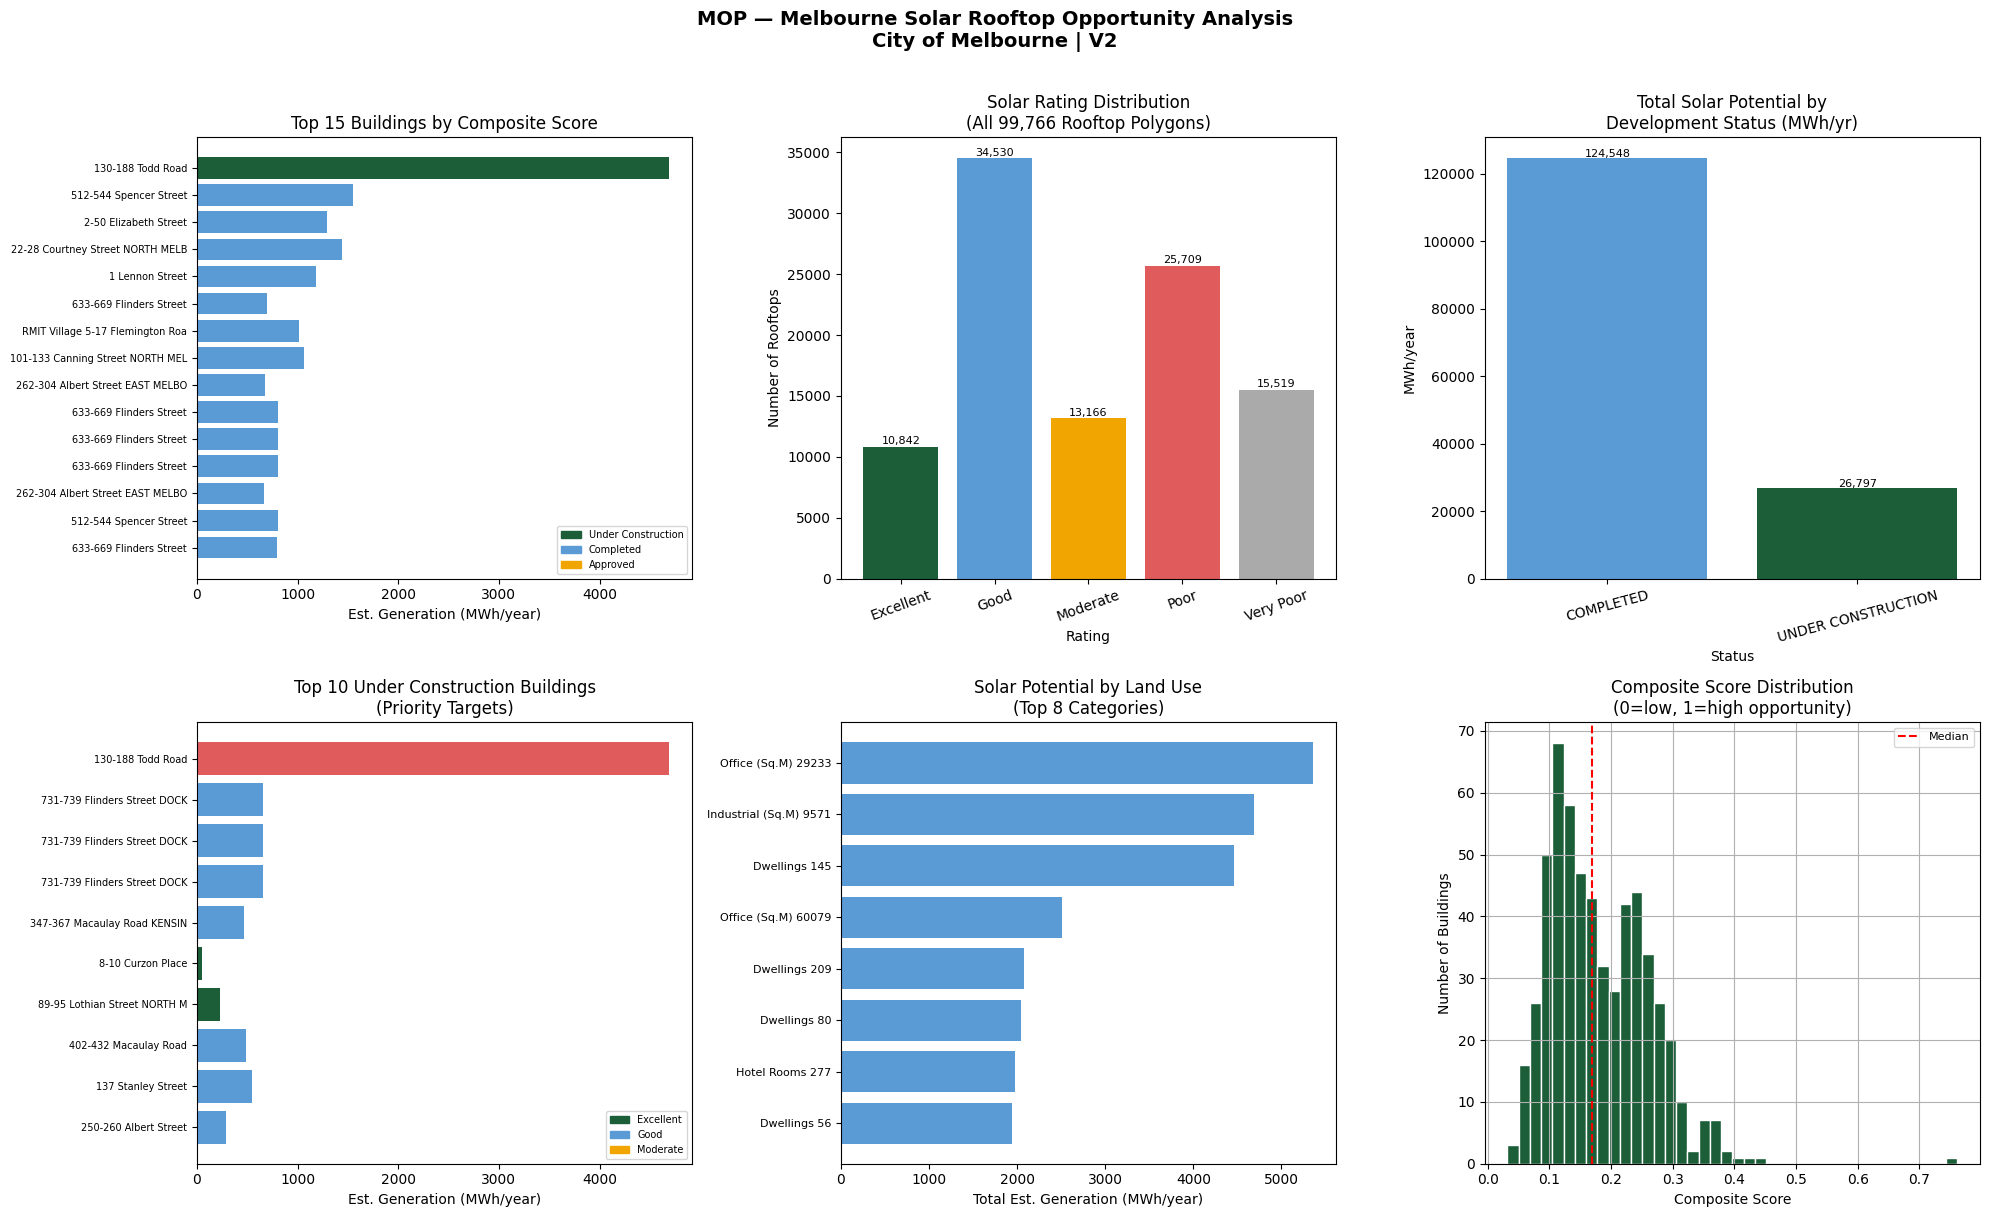

Dashboard saved to Google Drive!


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    'MOP — Melbourne Solar Rooftop Opportunity Analysis\nCity of Melbourne | V2',
    fontsize=14, fontweight='bold', y=1.01
)

# ── Chart 1: Top 15 Buildings by Composite Score ──────────────────────
ax1 = axes[0, 0]
top15 = building_summary.head(15).copy()
top15['short_addr'] = top15['address'].str.split(',').str[0].str[:32]
colors15 = [STATUS_COLOR.get(s, '#AAAAAA') for s in top15['status']]
bars = ax1.barh(range(len(top15)), top15['est_mwh_year'], color=colors15)
ax1.set_yticks(range(len(top15)))
ax1.set_yticklabels(top15['short_addr'], fontsize=7)
ax1.invert_yaxis()
ax1.set_xlabel('Est. Generation (MWh/year)')
ax1.set_title('Top 15 Buildings by Composite Score')
legend_patches = [
    mpatches.Patch(color='#1B5E38', label='Under Construction'),
    mpatches.Patch(color='#5B9BD5', label='Completed'),
    mpatches.Patch(color='#F0A500', label='Approved'),
]
ax1.legend(handles=legend_patches, fontsize=7, loc='lower right')

# ── Chart 2: Solar Rating Distribution ────────────────────────────────
ax2 = axes[0, 1]
rating_order  = ['Excellent', 'Good', 'Moderate', 'Poor', 'Very Poor']
rating_counts = solar['RATING'].value_counts().reindex(rating_order)
ax2.bar(rating_order, rating_counts.values,
        color=[RATING_COLOR[r] for r in rating_order])
ax2.set_title(f'Solar Rating Distribution\n(All {len(solar):,} Rooftop Polygons)')
ax2.set_xlabel('Rating')
ax2.set_ylabel('Number of Rooftops')
ax2.tick_params(axis='x', rotation=20)
for i, v in enumerate(rating_counts.values):
    ax2.text(i, v + 200, f'{v:,}', ha='center', fontsize=8)

# ── Chart 3: MWh by Status ────────────────────────────────────────────
ax3 = axes[0, 2]
status_energy = building_summary.groupby('status')['est_mwh_year'].sum().sort_values(ascending=False)
sc = [STATUS_COLOR.get(s, '#AAAAAA') for s in status_energy.index]
ax3.bar(status_energy.index, status_energy.values, color=sc)
ax3.set_title('Total Solar Potential by\nDevelopment Status (MWh/yr)')
ax3.set_xlabel('Status')
ax3.set_ylabel('MWh/year')
ax3.tick_params(axis='x', rotation=15)
for i, v in enumerate(status_energy.values):
    ax3.text(i, v + 200, f'{v:,.0f}', ha='center', fontsize=8)

# ── Chart 4: Top 10 Under Construction ───────────────────────────────
ax4 = axes[1, 0]
uc_top10 = uc.head(10).copy()
uc_top10['short_addr'] = uc_top10['address'].str.split(',').str[0].str[:28]
uc_colors = [RATING_COLOR.get(r, '#AAAAAA') for r in uc_top10['dominant_rating']]
ax4.barh(range(len(uc_top10)), uc_top10['est_mwh_year'], color=uc_colors)
ax4.set_yticks(range(len(uc_top10)))
ax4.set_yticklabels(uc_top10['short_addr'], fontsize=7)
ax4.invert_yaxis()
ax4.set_xlabel('Est. Generation (MWh/year)')
ax4.set_title('Top 10 Under Construction Buildings\n(Priority Targets)')
uc_legend = [mpatches.Patch(color=RATING_COLOR[r], label=r)
             for r in ['Excellent', 'Good', 'Moderate'] if r in RATING_COLOR]
ax4.legend(handles=uc_legend, fontsize=7)

# ── Chart 5: Land-Use Solar Potential ─────────────────────────────────
ax5 = axes[1, 1]
lu_top = land_use_summary.head(8)
ax5.barh(range(len(lu_top)), lu_top['total_mwh_year'], color='#5B9BD5')
ax5.set_yticks(range(len(lu_top)))
ax5.set_yticklabels(lu_top['land_use_1'], fontsize=8)
ax5.invert_yaxis()
ax5.set_xlabel('Total Est. Generation (MWh/year)')
ax5.set_title('Solar Potential by Land Use\n(Top 8 Categories)')

# ── Chart 6: Composite Score Distribution ─────────────────────────────
ax6 = axes[1, 2]
building_summary['composite_score'].hist(ax=ax6, bins=40, color='#1B5E38', edgecolor='white')
ax6.set_title('Composite Score Distribution\n(0=low, 1=high opportunity)')
ax6.set_xlabel('Composite Score')
ax6.set_ylabel('Number of Buildings')
ax6.axvline(building_summary['composite_score'].median(), color='red',
            linestyle='--', linewidth=1.5, label='Median')
ax6.legend(fontsize=8)

plt.tight_layout()
plt.savefig(BASE_PATH + 'solar_analysis_charts_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved to Google Drive!')

---
## Interactive Folium Map

**V2 improvements:**
- CO₂ offset shown in popup
- Homes equivalent shown in popup
- Composite score shown in popup
- Tooltip includes land-use category
- Buildings not matched to solar data shown in grey
- `LayerControl` to toggle COMPLETED vs UNDER CONSTRUCTION

In [18]:
# Merge building_summary stats onto projected footprints for geometry
map_data = footprints.merge(
    building_summary[[
        'dev_key', 'dominant_rating', 'est_mwh_year',
        'usable_area_m2', 'avg_rating_score', 'rank',
        'composite_score', 'est_co2_offset_t_year',
        'num_homes_equivalent', 'land_use_1', 'status'
    ]],
    on='dev_key',
    how='left'
)

# Derive priority_target fresh from the status column after merge
# (avoids suffix conflicts like status_x / status_y)
map_data['status'] = map_data['status_y'].fillna(map_data['status_x'])
map_data = map_data.drop(columns=['status_x', 'status_y'], errors='ignore')
map_data['priority_target'] = map_data['status'] == 'UNDER CONSTRUCTION'

# Convert to WGS84
map_wgs = map_data.to_crs(epsg=4326)

print('Columns in map_wgs:')
print(list(map_wgs.columns))
print(f'\nRows: {len(map_wgs):,}')
print(f'priority_target True: {map_wgs["priority_target"].sum()}')

Columns in map_wgs:
['dev_key', 'bldhgt_ahd', 'base_ahd', 'address', 'num_floors', 'land_use_1_x', 'shape_type', 'building_height_m', 'priority_target', 'is_actionable', 'geometry', 'dominant_rating', 'est_mwh_year', 'usable_area_m2', 'avg_rating_score', 'rank', 'composite_score', 'est_co2_offset_t_year', 'num_homes_equivalent', 'land_use_1_y', 'status']

Rows: 1,930
priority_target True: 299


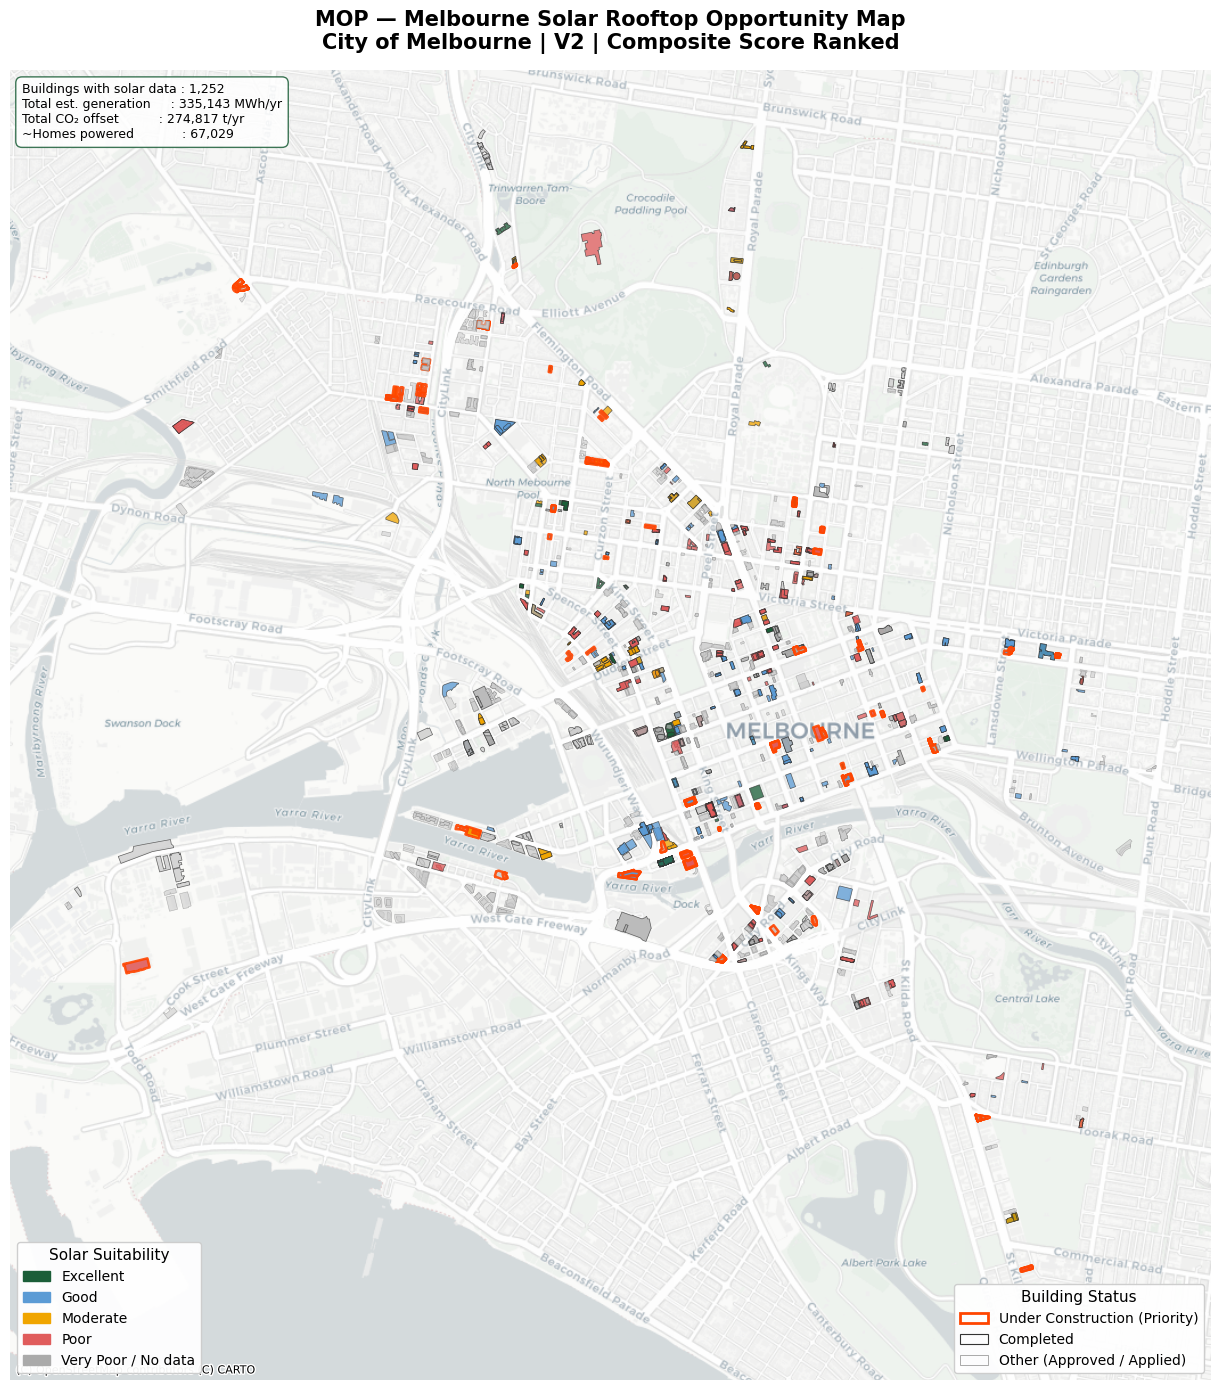

Map saved to Google Drive and displayed above.


In [19]:
# ── Build map ─────────────────────────────────────────────────────────
!pip install contextily

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
from matplotlib.colors import ListedColormap

# ── Install contextily if not present (for basemap tiles) ─────────────
# !pip install contextily -q

# ── Colour maps ───────────────────────────────────────────────────────
RATING_COLOR = {
    'Excellent': '#1B5E38',
    'Good':      '#5B9BD5',
    'Moderate':  '#F0A500',
    'Poor':      '#E05C5C',
    'Very Poor': '#AAAAAA'
}

# ── Reproject to Web Mercator (required for contextily basemap) ────────
map_wgs_plot = map_wgs.to_crs(epsg=3857)

# ── Assign colours based on dominant_rating ───────────────────────────
map_wgs_plot['fill_color'] = map_wgs_plot['dominant_rating'].map(RATING_COLOR).fillna('#CCCCCC')
map_wgs_plot['edge_color'] = map_wgs_plot['priority_target'].apply(
    lambda x: '#FF4500' if x else '#333333'
)
map_wgs_plot['linewidth'] = map_wgs_plot['priority_target'].apply(
    lambda x: 1.8 if x else 0.5
)

# ── Split by status for separate plotting ─────────────────────────────
completed = map_wgs_plot[map_wgs_plot['status'] == 'COMPLETED']
under_con = map_wgs_plot[map_wgs_plot['priority_target'] == True]
others    = map_wgs_plot[
    ~map_wgs_plot['status'].isin(['COMPLETED']) &
    (map_wgs_plot['priority_target'] == False)
]

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(16, 14))

# Plot each group
if len(completed) > 0:
    completed.plot(
        ax=ax,
        color=completed['fill_color'],
        edgecolor=completed['edge_color'],
        linewidth=0.5,
        alpha=0.75
    )

if len(under_con) > 0:
    under_con.plot(
        ax=ax,
        color=under_con['fill_color'],
        edgecolor='#FF4500',    # bright orange border = priority
        linewidth=1.8,
        alpha=0.9
    )

if len(others) > 0:
    others.plot(
        ax=ax,
        color=others['fill_color'],
        edgecolor='#888888',
        linewidth=0.4,
        alpha=0.6
    )

# ── Add basemap ───────────────────────────────────────────────────────
try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=14)
except Exception as e:
    print(f'Basemap not loaded: {e}')

# ── Title ─────────────────────────────────────────────────────────────
ax.set_title(
    'MOP — Melbourne Solar Rooftop Opportunity Map\n'
    'City of Melbourne | V2 | Composite Score Ranked',
    fontsize=15, fontweight='bold', pad=15
)

# ── Legend: Solar Suitability ─────────────────────────────────────────
rating_patches = [
    mpatches.Patch(color='#1B5E38', label='Excellent'),
    mpatches.Patch(color='#5B9BD5', label='Good'),
    mpatches.Patch(color='#F0A500', label='Moderate'),
    mpatches.Patch(color='#E05C5C', label='Poor'),
    mpatches.Patch(color='#AAAAAA', label='Very Poor / No data'),
]

# ── Legend: Status ────────────────────────────────────────────────────
status_patches = [
    mpatches.Patch(edgecolor='#FF4500', facecolor='none',
                   linewidth=2, label='Under Construction (Priority)'),
    mpatches.Patch(edgecolor='#333333', facecolor='none',
                   linewidth=0.8, label='Completed'),
    mpatches.Patch(edgecolor='#888888', facecolor='none',
                   linewidth=0.5, label='Other (Approved / Applied)'),
]

leg1 = ax.legend(
    handles=rating_patches,
    title='Solar Suitability',
    loc='lower left',
    framealpha=0.95,
    fontsize=10,
    title_fontsize=11
)
ax.add_artist(leg1)  # keep first legend visible

ax.legend(
    handles=status_patches,
    title='Building Status',
    loc='lower right',
    framealpha=0.95,
    fontsize=10,
    title_fontsize=11
)

# ── Stats annotation box ──────────────────────────────────────────────
total_mwh   = map_wgs_plot['est_mwh_year'].sum()
total_co2   = map_wgs_plot['est_co2_offset_t_year'].sum()
total_homes = map_wgs_plot['num_homes_equivalent'].sum()
n_buildings = map_wgs_plot['dominant_rating'].notna().sum()

stats_text = (
    f'Buildings with solar data : {n_buildings:,}\n'
    f'Total est. generation     : {total_mwh:,.0f} MWh/yr\n'
    f'Total CO₂ offset          : {total_co2:,.0f} t/yr\n'
    f'~Homes powered            : {total_homes:,.0f}'
)
ax.text(
    0.01, 0.99, stats_text,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='#1B5E38')
)

ax.set_axis_off()
plt.tight_layout()

# ── Save + show inline ────────────────────────────────────────────────
plt.savefig(BASE_PATH + 'solar_opportunity_map_v2.png', dpi=180, bbox_inches='tight')
plt.show()
print('Map saved to Google Drive and displayed above.')

---
##  Top-20 Priority Buildings — Export Table

In [14]:
top20 = building_summary.head(20)[[
    'rank', 'address', 'status', 'land_use_1', 'dominant_rating',
    'usable_area_m2', 'est_mwh_year', 'est_co2_offset_t_year',
    'num_homes_equivalent', 'composite_score', 'priority_target'
]].copy()

top20.columns = [
    'Rank', 'Address', 'Status', 'Land Use', 'Dominant Rating',
    'Usable Area (m²)', 'Est. MWh/yr', 'CO₂ Offset (t/yr)',
    '~Homes Powered', 'Composite Score', 'Priority (UC)'
]

out_table = BASE_PATH + 'top20_priority_buildings.csv'
top20.to_csv(out_table, index=False)
print(f'Top-20 table saved → {out_table}')
print()
print(top20.to_string(index=False))

Top-20 table saved → /content/drive/MyDrive/Colab Notebooks/MOP/top20_priority_buildings.csv

 Rank                                                    Address             Status                  Land Use Dominant Rating  Usable Area (m²)  Est. MWh/yr  CO₂ Offset (t/yr)  ~Homes Powered  Composite Score  Priority (UC)
    1                    130-188 Todd Road, Port Melbourne, 3207 UNDER CONSTRUCTION    Industrial (Sq.M) 9571            Poor           26832.0      4686.46            3842.90           937.3           0.7620           True
    2               512-544 Spencer Street, West Melbourne, 3003          COMPLETED             Dwellings 145            Good            7335.0      1549.31            1270.44           309.9           0.4356          False
    3                    2-50 Elizabeth Street, Kensington, 3031          COMPLETED       Office (Sq.M) 17609            Good            4917.0      1292.19            1059.59           258.4           0.4180          False
    4     

---
##  Results Summary

**V2 key improvements over V1:**

| Area | V1 | V2 |
|---|---|---|
| Panel efficiency | 15 % | 20 % (current market standard) |
| Peak sun hours | 4.5 h | 4.8 h (BOM Melbourne average) |
| Ranking metric | Raw MWh | Composite score (energy + quality) |
| Building height | Not derived | Computed from AHD delta |
| CO₂ offset | Not calculated | Estimated at 0.82 kg CO₂/kWh |
| Land-use analysis | None | Full breakdown by category |
| Map layers | Single layer | 3 toggle layers (COMPLETED / UC / Other) |
| Exported files | Charts + HTML map | + GPKG clean files + CSV top-20 |
| All 4 statuses in footprints | Filtered out APPROVED/APPLIED | Retained with `is_actionable` flag |